In [1]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print("✅ Libraries loaded!")


✅ Libraries loaded!


In [2]:
# Cell 2: Load all datasets
students = pd.read_csv('../data/raw/studentInfo.csv')
assessments = pd.read_csv('../data/raw/assessments.csv')
student_assessments = pd.read_csv('../data/raw/studentAssessment.csv')
student_vle = pd.read_csv('../data/raw/studentVle.csv')

print(f"✅ Loaded {len(students):,} students")
print(f"✅ Loaded {len(student_assessments):,} submissions")
print(f"✅ Loaded {len(student_vle):,} VLE interactions")

✅ Loaded 32,593 students
✅ Loaded 173,912 submissions
✅ Loaded 10,655,280 VLE interactions


In [3]:
# Cell 3: Examine student data
print("STUDENT DATA PREVIEW:")
print(students.head())
print("\nColumns:", students.columns.tolist())
print("\nFinal Results:")
print(students['final_result'].value_counts())
print("\nMissing values:")
print(students.isnull().sum())

STUDENT DATA PREVIEW:
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1               60    

SUBMISSION TIMING ANALYSIS:
count    171047.000000
mean        -16.657989
std          45.945880
min        -246.000000
25%          -6.000000
50%          -1.000000
75%           2.000000
max         372.000000
Name: days_to_deadline, dtype: float64

Late submissions: 49,318
Early submissions: 50,387


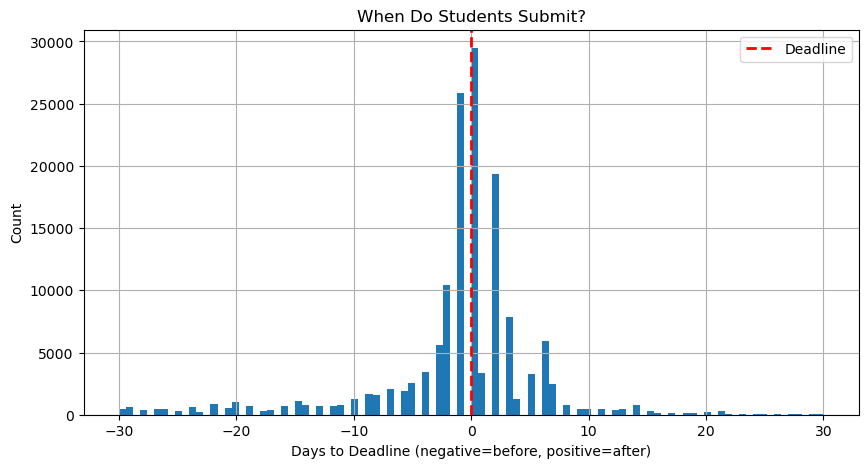

In [4]:
# Cell 4: Examine submission timing (KEY for procrastination!)
# Merge to get deadline vs submission date
submissions = student_assessments.merge(
    assessments[['id_assessment', 'date']], 
    on='id_assessment'
)
submissions.rename(columns={'date': 'deadline'}, inplace=True)

# Calculate days before deadline (negative = early, positive = late)
submissions['days_to_deadline'] = submissions['date_submitted'] - submissions['deadline']

print("SUBMISSION TIMING ANALYSIS:")
print(submissions['days_to_deadline'].describe())
print(f"\nLate submissions: {(submissions['days_to_deadline'] > 0).sum():,}")
print(f"Early submissions: {(submissions['days_to_deadline'] < -3).sum():,}")

# Visualize
plt.figure(figsize=(10, 5))
submissions['days_to_deadline'].hist(bins=100, range=(-30, 30))
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Deadline')
plt.xlabel('Days to Deadline (negative=before, positive=after)')
plt.ylabel('Count')
plt.title('When Do Students Submit?')
plt.legend()
plt.show()

LOGIN ACTIVITY BY OUTCOME:
              num_login_days  total_clicks
final_result                              
Distinction       118.258598   3106.433201
Fail               38.095434    794.416194
Pass               93.235013   2170.583448
Withdrawn          28.685309    628.148582


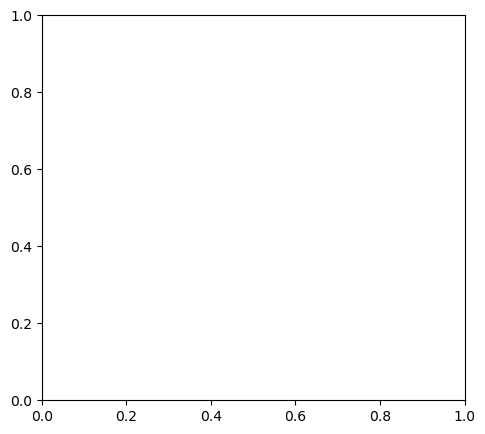

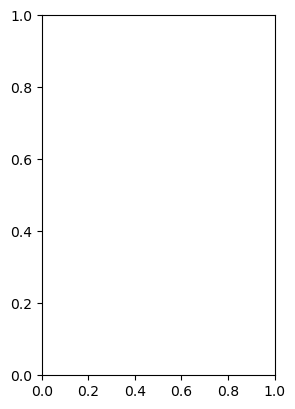

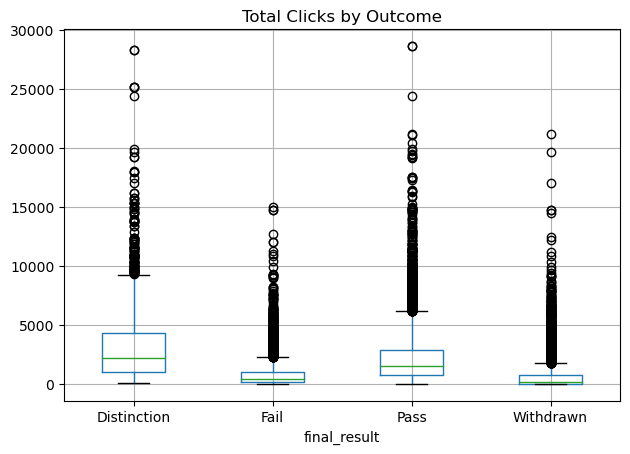

In [5]:
# Cell 5: Analyze login patterns
# Count login days per student
login_days = student_vle.groupby('id_student')['date'].nunique().reset_index()
login_days.columns = ['id_student', 'num_login_days']

# Total clicks per student
total_clicks = student_vle.groupby('id_student')['sum_click'].sum().reset_index()
total_clicks.columns = ['id_student', 'total_clicks']

# Merge with outcomes
activity = students[['id_student', 'final_result']].merge(
    login_days, on='id_student', how='left'
).merge(
    total_clicks, on='id_student', how='left'
).fillna(0)

print("LOGIN ACTIVITY BY OUTCOME:")
print(activity.groupby('final_result')[['num_login_days', 'total_clicks']].mean())

# Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
activity.boxplot(column='num_login_days', by='final_result')
plt.title('Login Days by Outcome')
plt.suptitle('')

plt.subplot(1, 2, 2)
activity.boxplot(column='total_clicks', by='final_result')
plt.title('Total Clicks by Outcome')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [6]:
# Cell 6: Identify procrastination patterns
# Group submission behavior per student
submission_patterns = submissions.groupby('id_student').agg({
    'days_to_deadline': ['mean', 'std', 'min', 'max'],
    'score': 'mean',
    'id_assessment': 'count'
}).reset_index()

# Flatten column names
submission_patterns.columns = ['id_student', 'avg_days_to_deadline', 
                                'std_days_to_deadline', 'earliest_submission',
                                'latest_submission', 'avg_score', 'num_submissions']

# Merge everything
full_data = students[['id_student', 'final_result']].merge(
    submission_patterns, on='id_student', how='left'
).merge(
    activity[['id_student', 'num_login_days', 'total_clicks']], 
    on='id_student', how='left'
)

print("PROCRASTINATION INDICATORS:")
print(full_data[['avg_days_to_deadline', 'num_login_days', 
                 'num_submissions']].describe())

# Save for later
full_data.to_csv('../data/processed/exploration_results.csv', index=False)
print("\n✅ Saved exploration results")

PROCRASTINATION INDICATORS:
       avg_days_to_deadline  num_login_days  num_submissions
count          34028.000000    40801.000000     34028.000000
mean             -11.898456       68.378103         8.222670
std               24.709416       60.819119         4.952153
min             -236.000000        0.000000         1.000000
25%              -15.343750       17.000000         4.000000
50%               -0.666667       53.000000         8.000000
75%                1.272727      106.000000        12.000000
max              163.222222      286.000000        28.000000

✅ Saved exploration results


In [7]:
# Cell 7: Clean the data
print("CLEANING DATA...")

# Fill missing values with 0 (students who didn't engage)
full_data = full_data.fillna(0)

print(f"✅ Shape after cleaning: {full_data.shape}")
print(f"✅ Missing values: {full_data.isnull().sum().sum()}")

CLEANING DATA...
✅ Shape after cleaning: (40801, 10)
✅ Missing values: 0


In [8]:
# Cell 8: Create procrastination features

# Feature 1: Last-minute ratio (submissions within 1 day / total)
last_minute = submissions[submissions['days_to_deadline'].abs() <= 1].groupby('id_student').size()
total_subs = submissions.groupby('id_student').size()
full_data['last_minute_ratio'] = full_data['id_student'].map(
    (last_minute / total_subs).fillna(0)
)

# Feature 2: Engagement intensity (clicks per login day)
full_data['engagement_intensity'] = np.where(
    full_data['num_login_days'] > 0,
    full_data['total_clicks'] / full_data['num_login_days'],
    0
)

# Feature 3: Deadline pressure (only count late days)
full_data['deadline_pressure'] = full_data['avg_days_to_deadline'].clip(lower=0)

# Feature 4: Login consistency (standard deviation of submission timing)
full_data['login_consistency'] = full_data['std_days_to_deadline'].fillna(0)

# Feature 5: Early starter (first submission >7 days before average deadline)
full_data['early_starter'] = (full_data['earliest_submission'] < -7).astype(int)

# Feature 6: Completion rate (submissions / expected)
# Assume 5 assessments per course on average
full_data['completion_rate'] = (full_data['num_submissions'] / 5).clip(upper=1.0)

# Feature 7: Activity span (range of submission dates)
full_data['activity_span'] = full_data['latest_submission'] - full_data['earliest_submission']

print("✅ 7 features created!")
print("\nFeature summary:")
feature_cols = ['last_minute_ratio', 'engagement_intensity', 'deadline_pressure',
                'login_consistency', 'early_starter', 'completion_rate', 'activity_span']
print(full_data[feature_cols].describe())

✅ 7 features created!

Feature summary:
       last_minute_ratio  engagement_intensity  deadline_pressure  \
count       34028.000000          40801.000000       40801.000000   
mean            0.376551             19.152956           0.960466   
std             0.289188             12.812174           3.012086   
min             0.000000              0.000000           0.000000   
25%             0.153846             10.945946           0.000000   
50%             0.333333             17.166667           0.000000   
75%             0.545455             25.631868           0.875000   
max             1.000000            157.705882         163.222222   

       login_consistency  early_starter  completion_rate  activity_span  
count       40801.000000   40801.000000     40801.000000   40801.000000  
mean           16.542172       0.373594         0.724095      44.737163  
std            28.407129       0.483764         0.395460      75.902209  
min             0.000000       0.000000   

TARGET VARIABLE DISTRIBUTION:
1    23688
0    17113
Name: high_risk, dtype: int64

High-risk percentage: 58.1%


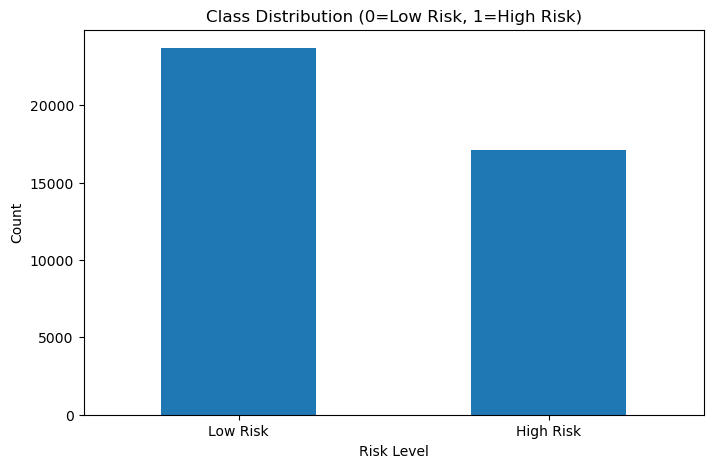

In [9]:
# Cell 9: Define high-risk procrastinators

# Label as high-risk if:
# 1. Failed or withdrew, OR
# 2. Consistently late (avg >3 days after deadline)
full_data['high_risk'] = (
    ((full_data['final_result'] == 'Fail') | 
     (full_data['final_result'] == 'Withdrawn')) |
    (full_data['avg_days_to_deadline'] > 3)
).astype(int)

print("TARGET VARIABLE DISTRIBUTION:")
print(full_data['high_risk'].value_counts())
print(f"\nHigh-risk percentage: {full_data['high_risk'].mean()*100:.1f}%")

# Visualize class balance
plt.figure(figsize=(8, 5))
full_data['high_risk'].value_counts().plot(kind='bar')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.title('Class Distribution (0=Low Risk, 1=High Risk)')
plt.xticks([0, 1], ['Low Risk', 'High Risk'], rotation=0)
plt.show()

In [10]:
# Cell 10: Export clean data

# Save complete dataset
full_data.to_csv('../data/processed/cleaned_data.csv', index=False)
print(f"✅ Saved complete data: {full_data.shape}")

# Save ML-ready subset (features + target only)
ml_cols = feature_cols + ['high_risk', 'id_student']
ml_data = full_data[ml_cols].copy()
ml_data.to_csv('../data/processed/ml_ready.csv', index=False)
print(f"✅ Saved ML-ready data: {ml_data.shape}")

print("\n📊 DATA SUMMARY:")
print(f"  Total students: {len(full_data):,}")
print(f"  Features: {len(feature_cols)}")
print(f"  High-risk: {full_data['high_risk'].sum():,}")
print(f"  Low-risk: {(~full_data['high_risk'].astype(bool)).sum():,}")

✅ Saved complete data: (40801, 18)
✅ Saved ML-ready data: (40801, 9)

📊 DATA SUMMARY:
  Total students: 40,801
  Features: 7
  High-risk: 23,688
  Low-risk: 17,113
